:::{admonition} Do this exercise yourself!
:class: important

This notebook is an exercise for practicing using plenoptic. You should work through it on your own, either by clicking on one of the following buttons or opening up a new notebook on your own machine and following along.

Regardless of which you choose, you should keep this page open for reference, as the links to other pages in the documentation (and some images) are broken in the downloaded and binder notebooks.

Download the executed notebook: **{nb-download}`introductory_tutorial.ipynb`**!

Run it in your browser: **{binder}`introductory_tutorial.ipynb`**!

:::

(full-intro)=
# Introductory Tutorial

The goal of this notebook is to give an introduction to plenoptic: we'll use two of our synthesis methods with a handful of models, and try to step through the kind of scientific reasoning that plenoptic's synthesis methods facilitate. Once you've completed it, we recommend working through the [exercises](exercises-index) to get more practice using plenoptic, and then read the parts of the documentation that interest you.

:::{admonition} Questions
:class: important

Throughout this notebook, there will be several questions that look like this. You are encouraged to stop and think about the question, to try and answer it yourself (perhaps looking at the hints that follow) before moving on and reading the answer below it.

:::

As described [in the introductory presentation video](https://archive.org/details/vss2025-symposium-plenoptic), the goal of plenoptic is to provide methods for model-based synthesis of stimuli, facilitating better understanding of how the models make sense of those stimuli: what information is discarded, what is important, etc. These methods have mostly been used on images, which we'll use here, but they also work on other types of stimuli as well.

In order to use plenoptic, we need some models! Normally, this will depend on your research problem: you'll use models that you've developed or fit in previous experiments, or that get used in the literature. For example, if you're studying V1, you could use an energy model of complex cells; if you're studying object recognition, you might use a deep network-based model.

<div class='render-all'>

For the purposes of this notebook, we'll use some very simple convolutional models that are inspired by the processing done in the lateral geniculate nucleus (LGN) of the visual system. (Most of these models were originally published in {cite:alp}`Berardino2017-eigen`, from which the figure is modified.)

<img src="../_static/lgn-models.png">

We're going to build up in complexity, starting with the Gaussian model at the top and gradually adding features. We'll describe the components of these models in more detail as we get to them, but briefly:

- {class}`~plenoptic.models.Gaussian`: the model just convolves a Gaussian with an image, so that the model's representation is simply a blurry version of the image.
- {class}`~plenoptic.models.CenterSurround`: the model convolves a difference-of-Gaussian filter with the image, so that model's representation is bandpass, caring mainly about frequencies that are neither too high or too low.
- {class}`~plenoptic.models.LuminanceGainControl`: the model rectifies and normalizes the linear component of the response using a local measure of luminance, so that the response is invariant to local changes in luminance.

(Note that {cite:alp}`Berardino2017-eigen` includes more models than described here. We're not examining all of them for time's sake, but you can check out the rest of the models described in the Berardino paper, they're all {ref}`included in plenoptic <models-api>`, under the header "LGN-inspired models".)

</div>

<div  class='render-user render-presenter' style="display:none">

What do the `render-user`, `render-presenter`, `render-all` classes / tags mean?

This file serves as a source file for three different versions of the same notebook:

- The "full" version, as displayed on the website, includes all code and full explanations.
- The "presenter" version would include all code and brief bullet point descriptions. It is intended as a reference for a presenter live-coding this notebook.
- The "user" version would include little code (replacing most code blocks with empty ones) and brief bullet point descriptions. It is intended as a "clean slate" for the presenter and users in a live-coding lesson.

In the plenoptic documentation, only the full version is used. However, the `render` tags and classes are left in to facilitate the creation of the other versions for workshops. Instead of setting custom css for the whole site to hide the `render-user` and `render-presenter` classes, as we do for the workshop websites, we instead use inline styles to hide them, as this will carry over if a user uses the download link at the top to download the notebook.

If you have downloaded this file locally and are seeing these sections alongside the lengthier explanations, just know that they are intended as terser restatements and notes, and we recommend paying more attention to the longer explanations; that is why they are hidden by default.

</div>

## Plenoptic basics

Let's get started! First, we'll import packages and set some configuration options:

In [1]:
import os

import matplotlib.pyplot as plt
import pyrtools as pt
import torch

import plenoptic as po

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print("Running on GPU!")
else:
    print("Running on CPU!")
# for reproducibility
po.set_seed(1)

# The default value of 500 for MAX_ITER here will lead to reasonable results, but will
# take too long if you don't have a GPU. If synthesis is taking a long time on your
# machine, set this to a lower value, but know that synthesis has ended early. View the
# website online to see what completed synthesis looks like.
MAX_ITER = int(os.environ.get("MAX_ITER", 500))
MAX_ITER_MED = MAX_ITER * 2
MAX_ITER_LONG = MAX_ITER * 10

Running on GPU!


In the following hidden cell, we define a helper function for creating some of the plots we'll use throughout this notebook.

In [2]:
def plot_helper(metamer, init_img=None):
    if init_img is None:
        init_img = metamer.saved_metamer[0]
    img = metamer.image[:1] if metamer.image.shape[0] > 1 else metamer.image
    to_plot = [torch.cat([torch.ones_like(img), img, metamer.model(img)])]
    for i, j in zip(init_img, metamer.metamer):
        to_plot.append(torch.stack([i, j, metamer.model(j)]))
    to_plot = torch.cat(to_plot)
    fig = po.plot.imshow(
        to_plot,
        col_wrap=3,
        title=["", "Original image", "Model representation\nof original image"]
        + 3
        * [
            "Initial image",
            "Synthesized metamer",
            "Model representation\nof synthesized metamer",
        ],
    )
    # change the color scale of the images so that the first two columns go from 0 to 1
    # and the last one is consistent
    for ax in fig.axes:
        if "representation" in ax.get_title():
            clim = (to_plot[2::3].min(), to_plot[2::3].max())
        else:
            clim = (0, 1)
        ax.images[0].set_clim(*clim)
        title = ax.get_title().split("\n")
        title[-2] = f" range: [{clim[0]:.01e}, {clim[1]:.01e}]"
        ax.set_title("\n".join(title))
    return fig

In addition to our models, all `plenoptic` methods require a "reference" or "target" image --- for Metamer synthesis, for example, this is the image whose representation we will match. Let's load in an image of Einstein to serve as our reference here. We'll also move Einstein to the GPU (if available) and to 64-bit floats, which improves reproducibility:

<div class='render-user render-presenter' style="display:none">

All synthesis methods require a "reference" or "target" image, so let's load one in.

</div>

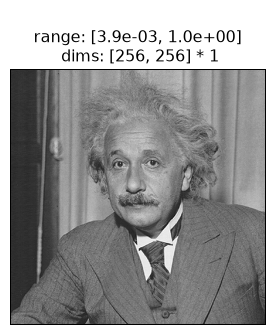

In [3]:
img = po.data.einstein().to(DEVICE).to(torch.float64)
fig = po.plot.imshow(img)

Models can be really simple, as this demonstrates. It needs to inherit `torch.nn.Module`[^module] and just needs two methods: `__init__` (so it's an object) and `forward` <!-- skip-lint --> (so it can take an image).

[^module]: Technically, this isn't necessary, but it will make your life easier. See {ref}`models-doc` for details.

To start, we'll create the `Gaussian` <!-- skip-lint --> model described above:

<div class='render-user render-presenter' style="display:none">

Set up the Gaussian model. Models in plenoptic must:
- Inherit `torch.nn.Module`.
- Have `forward` <!-- skip-lint --> and `__init__` methods.
- Accept tensors as input and return tensors as output.
- All operations performed must be torch-differentiable (i.e., come from the torch library)
- Have all model parameter gradients removed.

</div>

In [4]:
# Simple Gaussian convolutional model
class Gaussian(torch.nn.Module):
    # in __init__, we create the object, initializing the convolutional weights and
    # nonlinearity
    def __init__(self, kernel_size, std_dev=3):
        super().__init__()
        self.kernel_size = kernel_size
        self.conv = torch.nn.Conv2d(
            1, 1, kernel_size=kernel_size, padding=(0, 0), bias=False
        )
        # this is a convenience function for creating a simple Gaussian kernel
        self.conv.weight.data[0, 0] = po.process.circular_gaussian2d(
            kernel_size, std_dev
        )

    # the forward pass of the model defines how to get from an image to the
    # representation
    def forward(self, x):
        x = po.process.same_padding(x, self.kernel_size, pad_mode="circular")
        return self.conv(x)

To work with our synthesis methods, a model must accept a tensor as input and return a tensor as output. Here, we're working with 4d inputs: these are commonly used to represent images when working with pytorch models, and the dimensions are batch (often, multiple images), channel (often, RGB or outputs of different convolutional filters), height, and width. This is not required for a model to work with plenoptic's synthesis methods (3d, 5d, and other dimensionality inputs should work), but it is the convention in pytorch for representing images and several of the helper functions (especially those related to display) will not work if this is not the case. So we recommend only diverging from this convention if you need to represent non-image stimuli.

We can see that our `Gaussian` <!-- skip-lint --> model satisfies this constraint:

<div class="render-user render-all" style="display:none">

- Initialize the Gaussian model.
- Call it on our image.
- View the dimensionality of the model inputs and outputs.

</div>

In [5]:
# we pick this particular size kernel to match the models found in the Berardino paper
model = Gaussian((31, 31)).to(DEVICE).to(img.dtype)
rep = model(img)
print(img.shape)
print(rep.shape)

torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 256, 256])


This transformation between the input and the output must be handled in a pytorch-differentiable manner. As long as your model's `forward` <!-- skip-lint --> method only uses functions or objects from the pytorch library[^torch-only], you will satisfy this constraint. Additionally, you must not break the gradient computation by e.g., converting a tensor to a numpy array and back again, or using {external+torch:class}`torch.no_grad`.

Plenoptic provides a helper function {func}`plenoptic.validate.validate_model` to facilitate checking model compatibility: if `po.validate.validate_model(my_custom_model)` runs without an error, then you can use your model with our synthesis methods.

[^torch-only]: You *can* use functions from outside pytorch (e.g., numpy), if you write a custom `backward` method telling pytorch how to differentiate it, but this is difficult and we do not recommend it. See [pytorch docs](https://docs.pytorch.org/docs/main/notes/extending.html#extending-torch-autograd) for more details.

There's one final step before this model is ready for synthesis. Most `pytorch` models will have learnable parameters, such as the weights of the convolution filter we created above, because the focus is generally on training the model to best perform some task. In `plenoptic`, models are *fixed* because we take the opposite approach: generating some new stimulus to better a understand a given model. Thus, all synthesis methods will raise a `ValueError` if given a model with any learnable parameters. We provide a helper function to remove the gradients on these parameters, {func}`plenoptic.remove_grad`.

Similarly, you probably also want to call `.eval` <!-- skip-lint --> on any model, in case it has training-mode specific behavior: that's not the case here (we're just being pedantic), but it might be the case, depending on your model, and [pytorch's documentation](https://pytorch.org/docs/stable/notes/autograd.html#evaluation-mode-nn-module-eval) recommends calling `.eval` <!-- skip-lint --> just in case.

<div class="render-user render-all" style="display:none">

In plenoptic (unlike most uses of pytorch), models are *fixed*, so we:
- Remove gradients on model parameters.
- Switch model to `eval` <!-- skip-lint --> mode.

</div>

In [6]:
po.remove_grad(model)
model.eval()

Gaussian(
  (conv): Conv2d(1, 1, kernel_size=(31, 31), stride=(1, 1), bias=False)
)

Now that we've prepared our model, the following shows the input image and the model output. We can see that output is a blurred version of the input, as we would expect from a low-pass model.

<div class='render-user render-presenter' style="display:none">

- The Gaussian model output is a blurred version of the input.
- This is because the model is preserving the low frequencies,  discarding the high frequencies (i.e., it's a lowpass filter).
- Thus, this model is completely insensitive to high frequencies -- information there is invisible to the model.

</div>

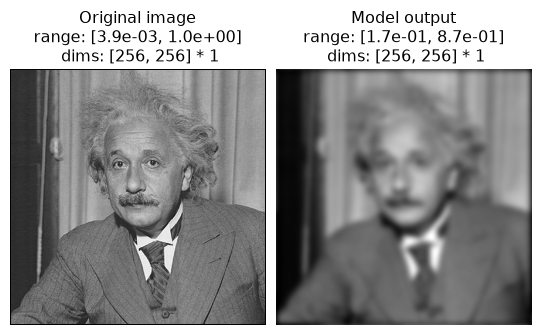

In [7]:
fig = po.plot.imshow([img, rep], title=["Original image", "Model output"])

Before moving forward, let's think about this model for a moment. It's a simple Gaussian convolution which throws out high-frequency information, as we can see in the representation above. Metamers provide a tool for exploring a model's insensitivities, so any metamers we synthesize should capitalize on this: they should differ from the original image in the high frequencies.

## Examining model invariances with metamers

Okay, now we're ready to start with metamer synthesis. To initialize, we only need the model and the image.

:::{admonition} Optional arguments
:class: dropdown note

While only the model and image are needed, you can set a variety of other optimization-related parameters, such as the loss function, learning rate, optimization algorithm, etc. In general, you'll probably need to play with these to find a good solution.

These arguments are passed to {class}`~plenoptic.Metamer` at initialization or the {func}`~plenoptic.Metamer.setup` method, which is optional (if you just want the defaults, you can skip it, as we do here).
:::

<div class='render-user render-presenter' style="display:none">

- Initialize the {class}`~plenoptic.Metamer` object and synthesize a model metamer.

</div>

In [8]:
metamer = po.Metamer(img, model)

matched_im = metamer.synthesize(store_progress=10, max_iter=20)
# if we call synthesize again, we resume where we left off. We'll also
# reduce stop_criterion, so synthesis runs for longer.
matched_im = metamer.synthesize(
    store_progress=10, max_iter=MAX_ITER, stop_criterion=1e-7
)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

{func}`~plenoptic.Metamer.synthesize` accepts a number of arguments which determine the duration of synthesis (such as `max_iter`, `stop_criterion`) and whether / how often to store the synthesized image-in-progress ({attr}`~plenoptic.Metamer.store_progress`). Here, we have set `store_progress=True` so that we can animate the synthesis process below.

After synthesis runs, we can examine the loss over time. There's a convenience function for this, but you could also call `plt.semilogy(metamer.losses)` to create it yourself.

<div class="render-user render-presenter" style="display:none">

- View the synthesis process.

</div>

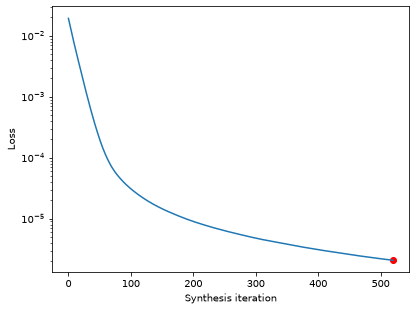

In [9]:
po.plot.synthesis_loss(metamer);

The loss decreases steadily and has reached a very low value. In fact, based on our convergence criterion (one of the optional arguments to {func}`~plenoptic.Metamer.synthesize`), it looks as though we've converged (we could decrease this argument to run synthesis for longer).

We can also view a movie of our synthesis progress:

:::{important}
This next cell will take a while to run --- making animations in matplotlib is a bit of a slow process.
:::

In [10]:
po.plot.synthesis_animate(
    metamer, included_plots=["synthesis_imshow", "synthesis_loss"], figsize=(12, 5)
)

In the above, we see that we start with white noise, and gradually update the pixel values so as to make the model's representation of this image the same as that of our target Einstein image.

We can then look at the reference and metamer images, as well as the model's outputs on the two images:

<div class="render-user render-presenter" style="display:none">

- Visualize model metamers.

</div>

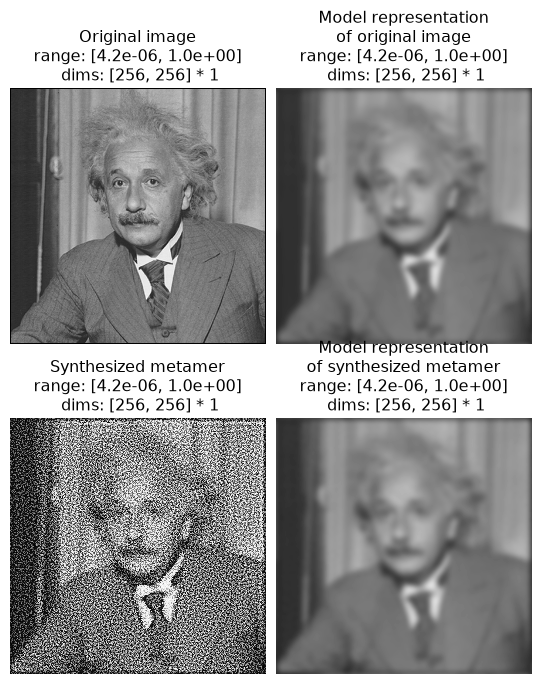

In [11]:
fig = po.plot.imshow(
    [img, rep, metamer.metamer, model(metamer.metamer)],
    col_wrap=2,
    vrange="auto1",
    title=[
        "Original image",
        "Model representation\nof original image",
        "Synthesized metamer",
        "Model representation\nof synthesized metamer",
    ],
);

In the above figure, the left column shows the images and the right column the model outputs; top row shows the original image and bottom the synthesized metamer.

We can see that, even though the target and synthesized images look very different, the two model outputs look basically identical (which matches the exceedingly low loss value we saw above).

:::{admonition} Question
:class: important

Why does the model metamer look "staticky"?
:::

:::{admonition} Hint
:class: hint dropdown

Model metamers help us examine the model's nullspace, its invariances. A Gaussian is a lowpass filter, so what information is it insensitive to?
:::

It may seem strange that the synthesized image looks like it has high-frequency noise in it --- a Gaussian is a low-pass filter, so why isn't the model metamer just a blurred version of the original image? Indeed, such a blurred image would be a model metamer, but it's only one of many. Remember what we mentioned earlier: Gaussians are insensitive to high-frequency information, which not only means that their response doesn't change when you remove that information, but that you can put any amount of high frequency information into an image without affecting the model's output. Put another way, you can randomize the contents of the model's null space without affecting its response, and the goal of metamer synthesis is to generate different images that do just that.

We can see the model's insensitivity to high frequencies more dramatically by initializing our metamer synthesis with a different image. By default, we initialize with a patch of white noise, but we can initialize with any image of the same size. Let's try with two different images, a sample of pink noise and a picture of Marie Curie.

<div class='render-user render-presenter' style="display:none">

- Synthesize more model metamers, from different starting points.

</div>

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-481/lib/python3.12/site-packages/pyrtools/tools/synthetic_images.py:133: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = np.power(r, exponent / 2.0, where=(r != 0))


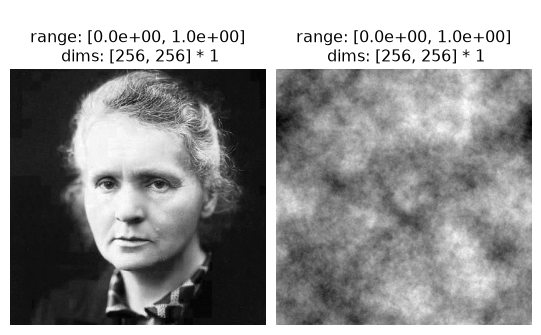

In [12]:
curie = po.data.curie().to(DEVICE).to(img.dtype)
# pyrtools, imported as pt, has a convenience function for generating samples of white
# noise, but then we need to convert the image to a torch tensor...
pink = torch.from_numpy(pt.synthetic_images.pink_noise((256, 256)))
# ... which is 4d ...
pink = pink.unsqueeze(0).unsqueeze(0)
# ... whose values lie between 0 and 1, and is the right dtype and device
pink = po.process.rescale(pink).to(img.dtype).to(DEVICE)
po.plot.imshow([curie, pink]);

We run synthesis in the same way as before, just passing the optional argument `initial_image` <!-- skip-lint --> to {func}`~plenoptic.Metamer.setup`:

In [13]:
metamer_curie = po.Metamer(img, model)
metamer_curie.setup(initial_image=curie)
metamer_pink = po.Metamer(img, model)
metamer_pink.setup(initial_image=pink)

# we increase the length of time we run synthesis and decrease the
# stop_criterion, which determines when we think loss has converged
# for stopping synthesis early.
metamer_curie.synthesize(max_iter=MAX_ITER, stop_criterion=1e-7)
metamer_pink.synthesize(max_iter=MAX_ITER, stop_criterion=1e-7)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

Let's double-check that our synthesis looks like it's reached a good solution by checking the loss curve:

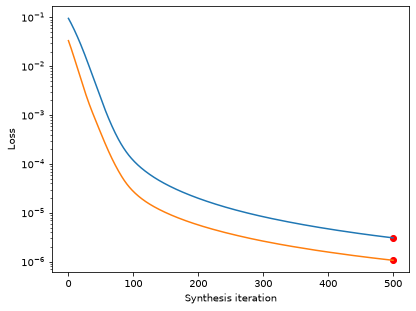

In [14]:
po.plot.synthesis_loss(metamer_curie)
po.plot.synthesis_loss(metamer_pink);

<div class='render-user render-presenter' style="display:none">

Visualize all metamer outputs. In the plot we will create:
- the first row shows our target Einstein image and its model representation, as we saw before.
- the new three rows show our model metamers resulting from three different starting points.
- in each, the first column shows the starting point of our metamer synthesis, the middle shows the resulting model metamer, and the third shows the model representation.

We can see that the model representation is the same for all four images, but the images themselves look very different. Because the model is completely invariant to high frequencies, the high frequencies present in the initial image are not affected by the synthesis procedure and thus are still present in the model metamer.

</div>

Good, now let's examine our synthesized metamer and the model output for all our initial images:

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


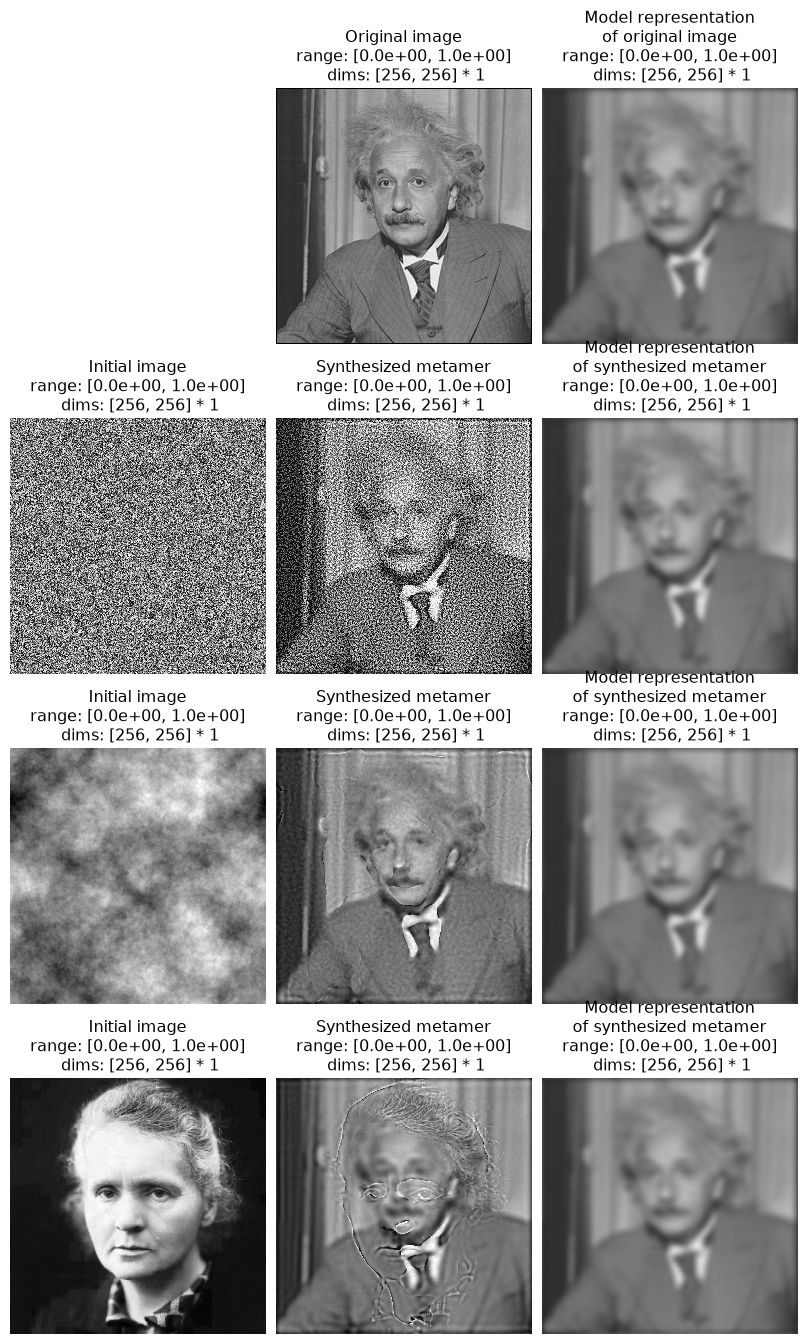

In [15]:
fig = po.plot.imshow(
    [
        torch.ones_like(img),
        img,
        rep,
        metamer.saved_metamer[0],
        metamer.metamer,
        model(metamer.metamer),
        pink,
        metamer_pink.metamer,
        model(metamer_pink.metamer),
        curie,
        metamer_curie.metamer,
        model(metamer_curie.metamer),
    ],
    col_wrap=3,
    vrange="auto1",
    title=["", "Original image", "Model representation\nof original image"]
    + 3
    * [
        "Initial image",
        "Synthesized metamer",
        "Model representation\nof synthesized metamer",
    ],
)
fig.axes[0].set_visible(False)
fig.set(tight_layout=True);

In the above figure, the first row shows our original image and its representation and each subsequent row shows the result of a separate metamer synthesis: the first column shows our initial image, the second the synthesized metaer, and the third the representation of that metamer.

We see that the new synthesized metamers looks quite different from both the original and from our previous metamer, while the model outputs of all the images look very similar. In the third row, the synthesized model metamer looks like a blurry picture of Einstein with a high-frequency "shadow" of Curie added on top. Again, this is because the Gaussian model is insensitive to high frequencies, and thus a model metamer can include any high frequency information. In the final row, we can see that our model metamer looks like a blurry picture of Einstein --- because pink noise has very little information in the high frequencies (and the information that is present is incoherent), our resulting metamer appears to have little information present.

## Examining model sensitivities to eigendistortions

By generating model metamers, we've gained a better understanding of the information our model is invariant to, but what if we want a better understanding of what our model is sensitive to? We can use {class}`~plenoptic.Eigendistortion` for that.

Like {class}`~plenoptic.Metamer`, {class}`~plenoptic.Eigendistortion` accepts an image and a model as its inputs. By default, it synthesizes the top and bottom eigendistortion, that is, the changes to the input image that the model finds most and least noticeable.

<div class='render-user render-presenter' style="display:none">

- While metamers allow us to examine model invariances, eigendistortions allow us to also examine model sensitivities.
- Eigendistortions are distortions that the model thinks are the most and least noticeable.

</div>

In [16]:
eig = po.Eigendistortion(img, model)
eig.synthesize(max_iter=MAX_ITER_MED);

Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Let's examine those distortions:

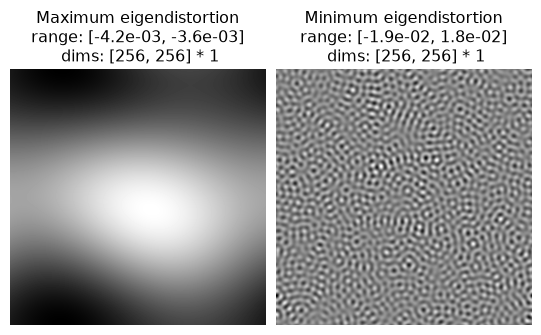

In [17]:
po.plot.imshow(
    eig.eigendistortions, title=["Maximum eigendistortion", "Minimum eigendistortion"]
);

We can see they make sense: the most noticeable distortion is a very low-frequency modification to the image, with a period of about half the image. The least noticeable, on the other hand, is very high-frequency, which matches our understanding from the metamer example above. This matches our understanding of how a lowpass filter works.

## A more complex model

Now we feel pretty confident that we understand how a simple Gaussian works, what happens when we make the model more complicated? Let's try changing the filter from a simple lowpass to a bandpass filter, which have sensitivities more similar to those of neurons in the early human visual system. To do this, we'll use plenoptic's built-in {class}`~plenoptic.models.CenterSurround` object:

<div class='render-user render-presenter' style="display:none">

- The {class}`~plenoptic.models.CenterSurround` model has bandpass sensitivity, as opposed to the lowpass sensitivity of the `Gaussian` <!-- skip-lint -->.
- Thus, it is still insensitive to the highest frequencies, but it is less sensitive to the low frequencies the Gaussian prefers, with its peak sensitivity lying in a middling range.

</div>

In [18]:
# These values come from Berardino et al., 2017.
center_surround = po.models.CenterSurround(
    (31, 31), center_std=1.962, surround_std=4.235, pad_mode="circular"
)
center_surround = center_surround.to(DEVICE).to(img.dtype)
po.remove_grad(center_surround)
center_surround.eval()
center_surround(img).shape

torch.Size([1, 1, 256, 256])

Before synthesizing our metamers, let's look at the model representation:

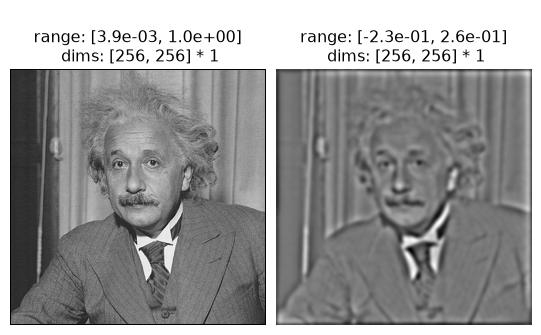

In [19]:
po.plot.imshow([img, center_surround(img)]);

While the Gaussian model above was lowpass, throwing away high frequencies and preserving the low, the Center-Surround model is bandpass. It is thus most sensitive to frequencies found in the middle, and less sensitive to both high and low frequencies[^bandpass]. We can see that in the figure above because the image looks "sharper" than the Gaussian representation (showing that it contains more high frequencies) while also being an overall "mean gray" (showing that it is discarding the low frequencies that account for making portions of the image dark or light).

We can make use of multi-batch processing in order to synthesize the metamers with different start points, as above, using a single {class}`~plenoptic.Metamer` object:

<div class='render-user render-presenter' style="display:none">

- We can synthesize all three model metamers at once by taking advantage of multi-batch processing.

</div>

In [20]:
white_noise = po.process.rescale(torch.rand_like(img), a=0, b=1).to(DEVICE)
init_img = torch.cat([white_noise, pink, curie], dim=0)
# metamer does a 1-to-1 matching between initial and target images,
# so we need to repeat the target image on the batch dimension
cs_metamer = po.Metamer(img.repeat(3, 1, 1, 1), center_surround)
cs_metamer.setup(initial_image=init_img)
cs_metamer.synthesize(MAX_ITER_MED, stop_criterion=1e-10)

  0%|          | 0/1000 [00:00<?, ?it/s]

Now let's visualize our outputs (the code to create this plot is slightly annoying, so we're defined it as a helper function at the top of the notebook):

<div class="render-user render-presenter" style="display:none">

- Visualize all the model metamers we synthesized.

</div>

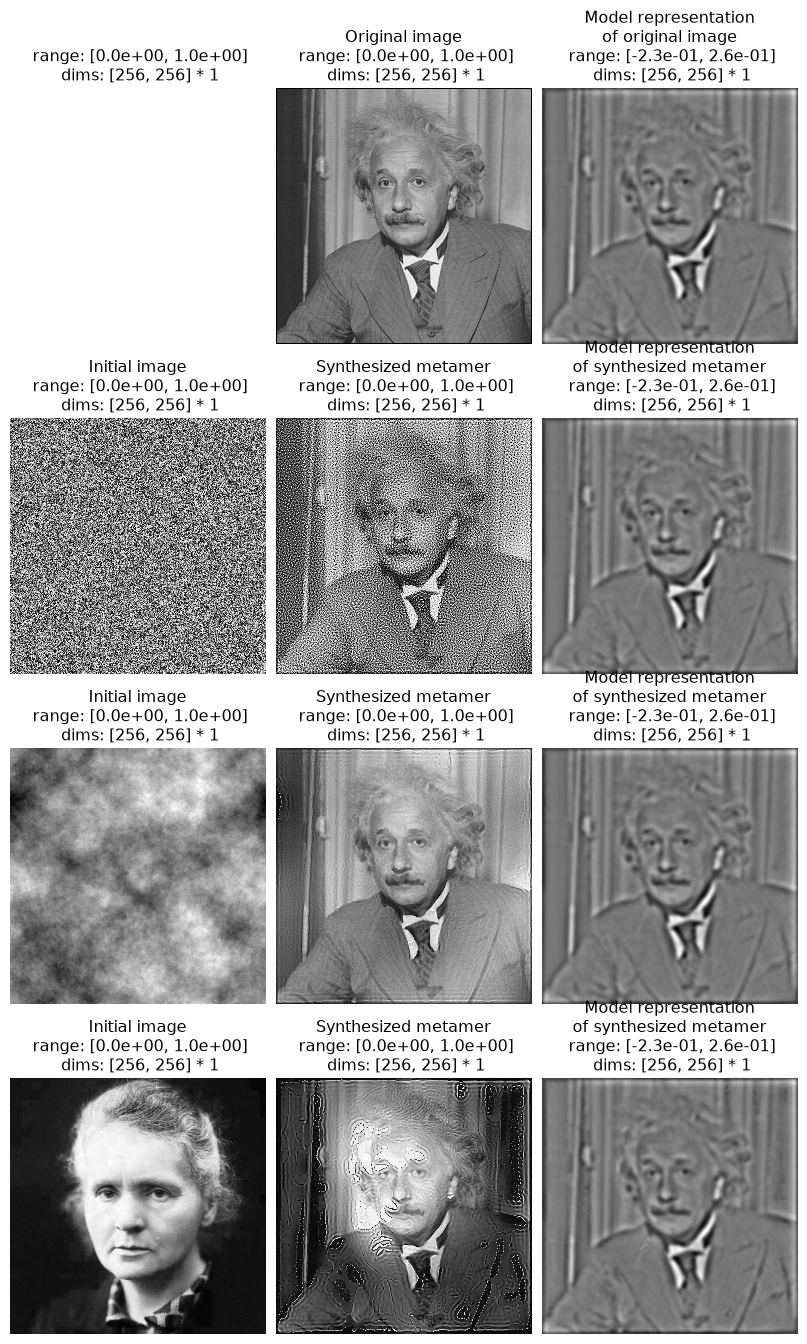

In [21]:
plot_helper(cs_metamer, init_img);

The layout of the plots here is the same as before: the top row shows our target image and its model representation, while the next rows each show a separate model metamer in the middle column, with their different initial points in the left column and their model representations on the right. We can see that the model representation in each row looks the same, while the middle columns look very different.

:::{admonition} Question
:class: important

How do these model metamers differ from the Gaussian ones? How does that relate to what we know about the model's sensitivities and invariances?
:::

While these model metamers look reasonably similar to the metamers of the `Gaussian` <!-- skip-lint --> model, a somewhat blurry Einstein with some additional info riding on top, if we look carefully, we can notice some important differences:

- in the white noise metamer, the mean values appear to be different: the dark side of the room on the left side of the picture, as well as his suit, appear to be lighter.
- whereas the `Gaussian` <!-- skip-lint --> pink noise metamer just appeared to be blurry, the {class}`~plenoptic.models.CenterSurround` one has dark and light patches that roughly match up with the original noise seed.
- the differences are most striking in the Curie metamer, as the initial image was completely black except for Marie Curie's face, which is fairly white. The resulting metamer, therefore, is much darker than the target everywhere except the center of the image, which is much brighter.

In all of these, the differences are the result of the fact that our model now consists of a [difference-of-Gaussians filter](https://en.wikipedia.org/wiki/Difference_of_Gaussians) rather than a Gaussian. As described earlier, this results in a model with *bandpass* selectivity, rather than *lowpass*. Thus, the {class}`~plenoptic.models.CenterSurround` doesn't care about low frequency information like the local mean pixel value and we can change it without affecting its output[^bandpass].

[^bandpass]: The {class}`~plenoptic.models.CenterSurround` model does retain some sensitivity to lower frequencies, but it's much less sensitive to them than the `Gaussian` <!-- skip-lint --> model is. The {class}`~plenoptic.models.CenterSurround` retains some low frequency selectivity because its two Gaussians are not perfectly balanced; to play around with their balance, try changing the `amplitude_ratio` argument.

The change from a lowpass to a bandpass model also changes the model's most sensitive frequencies, though we can't easily tell that using model metamers. We can, however, using eigendistortions!

<div class='render-user render-presenter' style="display:none">

- By examining the eigendistortions, we can see more clearly that the model's preferred frequency has shifted higher, while the minimal eigendistortion still looks fairly similar.

</div>

Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

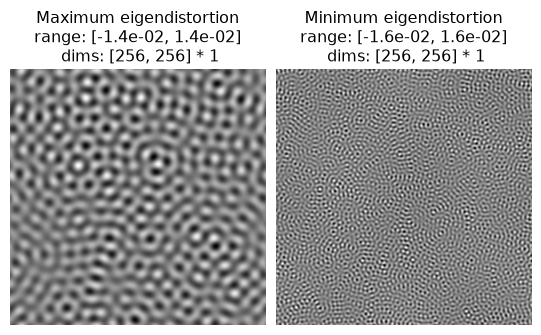

In [22]:
cs_eig = po.Eigendistortion(img, center_surround)
cs_eig.synthesize(max_iter=MAX_ITER_MED)
po.plot.imshow(
    cs_eig.eigendistortions,
    title=["Maximum eigendistortion", "Minimum eigendistortion"],
);

In this case, we can see that the minimum eigendistortion looks similar to that of the `Gaussian` <!-- skip-lint -->: an unoriented pattern of high-frequency noise. The maximum eigendistortion, however, has a much higher frequency than that of the `Gaussian` <!-- skip-lint -->, corresponding to the change in the filter.

## Adding some nonlinear features to the mix

So far, our models have all been linear. That means that they're relatively easy to understand, and we could indeed infer much of the information above by just looking at the Fourier transform of the model's filter[^fft]. However, if we add nonlinear features, analysis of model selectivity becomes trickier. To see what this looks like, let's use the {class}`~plenoptic.models.LuminanceGainControl` model, which adds gain control[^gaincontrol]: we take the output of the filter and divide it by the local luminance.

[^fft]: Try it yourself!
    ```python
    cs_filt = center_surround.filt
    gauss_filt = model.conv.weight.data
    filts = torch.cat([cs_filt, gauss_filt], dim=0)
    energy = torch.fft.fftshift(torch.fft.fft2(filts).abs())
    po.plot.imshow(energy)
    ```
[^gaincontrol]: Gain control, or divisive normalization, is ubiquitous in the central nervous system and has been proposed as a [canonical neural computation](https://www.nature.com/articles/nrn3136) which allows the brain to maximize sensitivity to relevant stimuli in changing contexts.

<div class='render-user render-presenter' style="display:none">

- The {class}`~plenoptic.models.LuminanceGainControl` model adds a nonlinearity, gain control. This makes the model harder to reason than the first two models.
- This model divides the output of the {class}`~plenoptic.models.CenterSurround` filter with an estimate of local luminance (the output of a larger Gaussian filter), which makes the model completely insensitive to absolute pixel values. It now cares about contrast, rather than luminance.
- This is a computation that we think is present throughout much of the early visual system.

</div>

In [23]:
lg = po.models.LuminanceGainControl(
    (31, 31), pad_mode="circular", pretrained=True, cache_filt=True
)
lg = lg.to(DEVICE).to(img.dtype)
po.remove_grad(lg)
lg.eval()

LuminanceGainControl(
  (center_surround): CenterSurround()
  (luminance): Gaussian()
)

This builds in additional invariances to the model, making it explicitly less sensitive to changes in the local luminance, so that if you double all the pixel values in the image, the model's response remains the same:

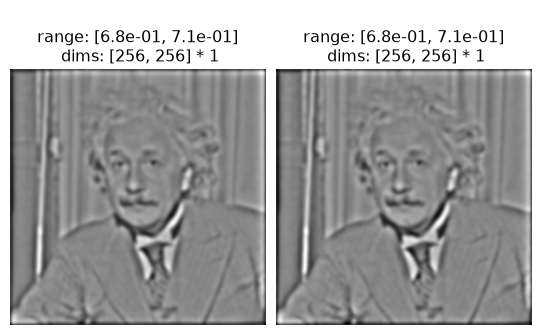

In [24]:
po.plot.imshow([lg(img), lg(2 * img)], vrange="auto1");

Notice that not just the two plotted images but also their range (given in the title) are identical.

Now let's go ahead and synthesize and visualize metamers for this model. The code will look the same as before, except we're going to set the learning rate to a value slightly lower than the default, which allows us to find a better solution here.

<div class='render-user render-presenter' style="display:none">

- Let's synthesize and visualize some metamers for this model.

</div>

In [25]:
lg_metamer = po.Metamer(img.repeat(3, 1, 1, 1), lg)
lg_metamer.setup(initial_image=init_img, optimizer_kwargs={"lr": 0.007})
lg_metamer.synthesize(MAX_ITER_LONG, stop_criterion=1e-12)

  0%|          | 0/5000 [00:00<?, ?it/s]

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-481/lib/python3.12/site-packages/plenoptic/_synthesize/metamer.py:380: UserWarning: Loss has converged, stopping synthesis
  warnings.warn("Loss has converged, stopping synthesis")


And let's visualize our results:

<div class='render-presenter' style="display:none">

- The model metamers here look fairly similar to those of the {class}`~plenoptic.models.CenterSurround` model, though you can see that their local luminance is even more similar to the initial image, because this model is even less sensitive to the local luminance than the previous model.

</div>

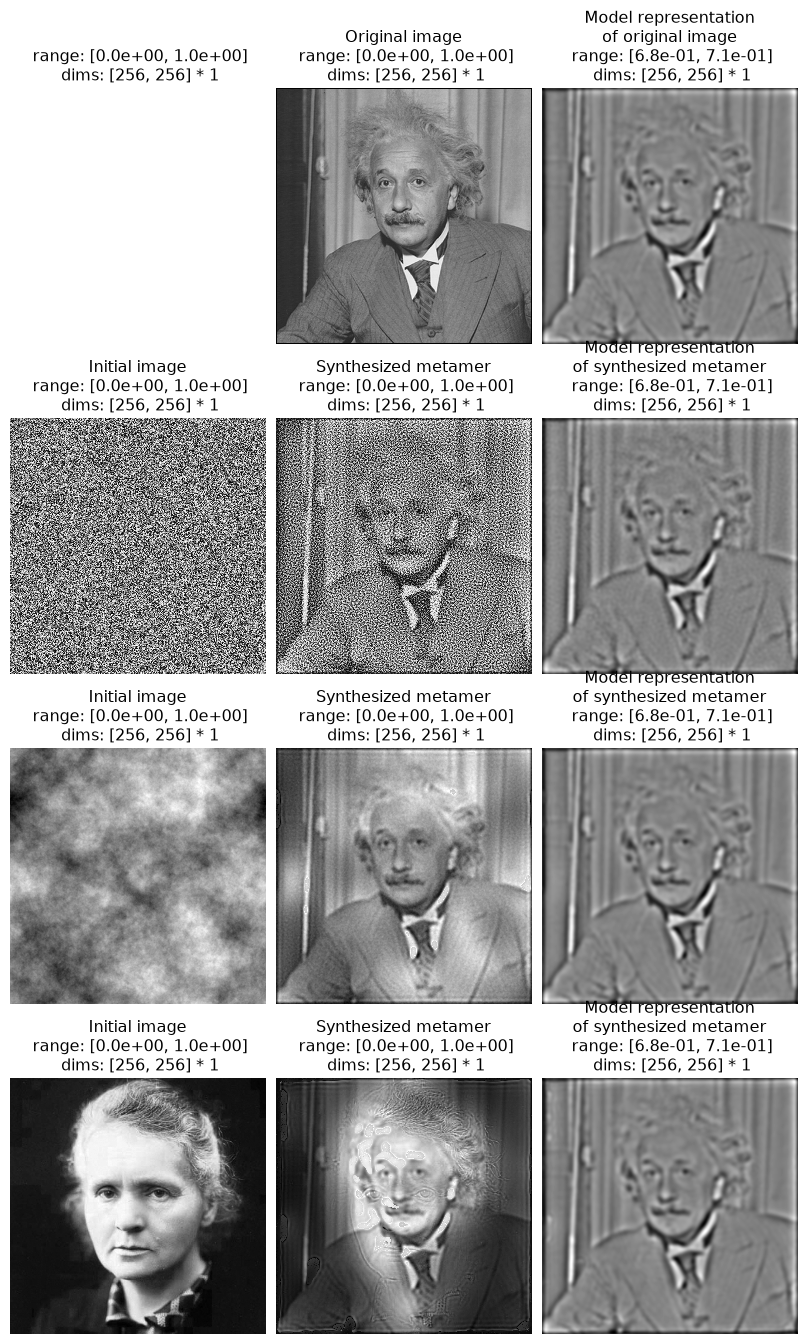

In [26]:
plot_helper(lg_metamer, init_img);

We can see that the {class}`~plenoptic.models.LuminanceGainControl` model metamers look somewhat similar to that of the {class}`~plenoptic.models.CenterSurround` model, but taking the insensitivity to pixel values to an extreme --- because of the division by the local luminance, the model is completely invariant to it, so that the mean pixel values match those of the initializing image, fairly dramatically.

Finally, let's look at our eigendistortions:

<div class='render-user render-presenter' style="display:none">

- Now let's use eigendistortions to see what this model is particularly sensitive to.

</div>

Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Bottom k=1 eigendists computed | Stop criterion 1.00E-07 reached.


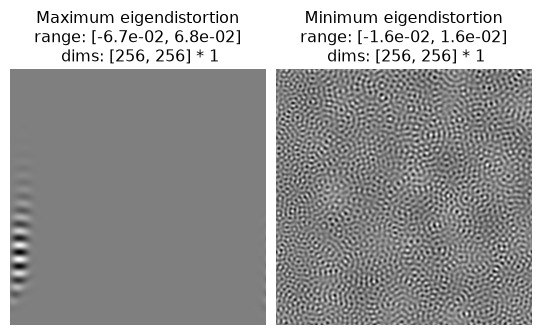

In [27]:
lg_eig = po.Eigendistortion(img, lg)
lg_eig.synthesize(max_iter=MAX_ITER_MED)
po.plot.imshow(
    lg_eig.eigendistortions,
    title=["Maximum eigendistortion", "Minimum eigendistortion"],
);

:::{admonition} Question
:class: important

How do these eigendistortions compare to that of the {class}`~plenoptic.models.CenterSurround` model? Why do they, especially the maximum eigendistortion, look more distinct from those of the {class}`~plenoptic.models.CenterSurround` model than the metamers do?
:::

:::{admonition} Hint
:class: hint dropdown

The maximum eigendistortion emphasizes what the model is *most* sensitive to (whereas metamers focus on model invariances), so what about the `LinearGainControl` model's nonlinearities would cause this change?
:::

Again, the minimum eigendistortion looks fairly similar to before, but now our maximum eigendistortion looks quite different: it's a series of black and white stripes at defined location and orientation. This is a slightly subtle point: without gain control, the simple convolutional models we were investigating view changes everywhere in the image as equivalent and, therefore, a good strategy is to spread out the changes across the whole image. Now, however, gain control means that the model gives different outputs to the same frequency content depending on the local luminance; thus, it matters whether the distortion is placed in a dark or light portion of the image.

This adaptivity matters not just within images, but across images: the {class}`~plenoptic.models.CenterSurround` and `Gaussian` <!-- skip-lint --> models' eigendistortions look the same on different images, whereas {class}`~plenoptic.models.LuminanceGainControl`'s eigendistortions vary depending on the image content:

<div class='render-presenter' style="display:none">

- Gain control makes this model adaptive, and thus the location of the eigendistortion matters, which was not true of our previous, linear models.

</div>

Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Bottom k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Top k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

Top k=1 eigendists computed | Stop criterion 1.00E-07 reached.


Bottom k=1 eigendists:   0%|          | 0/1000 [00:00<?, ?it/s]

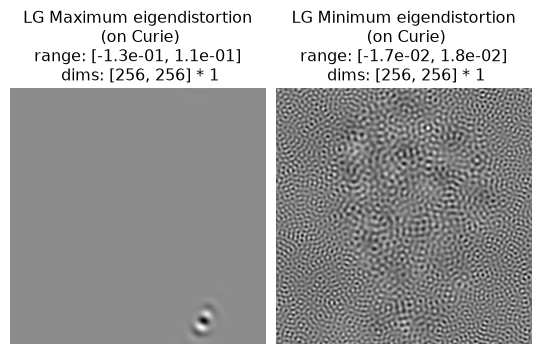

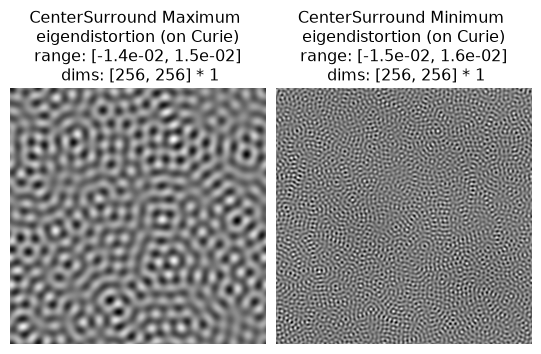

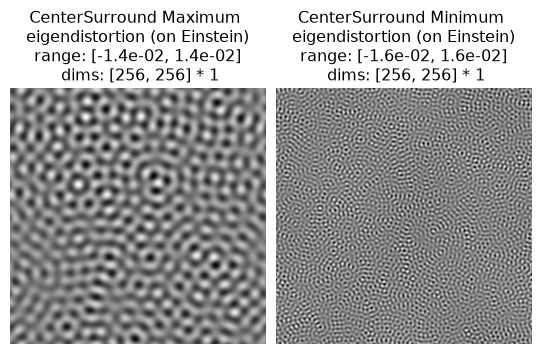

In [28]:
lg_curie_eig = po.Eigendistortion(curie, lg)
lg_curie_eig.synthesize(max_iter=MAX_ITER_MED)
po.plot.imshow(
    lg_curie_eig.eigendistortions,
    title=[
        "LG Maximum eigendistortion\n (on Curie)",
        "LG Minimum eigendistortion\n (on Curie)",
    ],
)
cs_curie_eig = po.Eigendistortion(curie, center_surround)
cs_curie_eig.synthesize(max_iter=MAX_ITER_MED)
po.plot.imshow(
    cs_curie_eig.eigendistortions,
    title=[
        "CenterSurround Maximum \neigendistortion (on Curie)",
        "CenterSurround Minimum \neigendistortion (on Curie)",
    ],
)
po.plot.imshow(
    cs_eig.eigendistortions,
    title=[
        "CenterSurround Maximum \neigendistortion (on Einstein)",
        "CenterSurround Minimum \neigendistortion (on Einstein)",
    ],
);

We've plotted the {class}`~plenoptic.models.CenterSurround` eigendistortions for comparison and we can see that, while they're not identical, they look essentially the same, regardless of the image: bandpass unoriented noisy patterns for the maximum distortion and the same pattern at a higher frequency for the minimum. The {class}`~plenoptic.models.LuminanceGainControl` eigendistortions, by comparison, vary based on the image. They are, however, consistent with each other: in both cases, the {class}`~plenoptic.models.LuminanceGainControl` maximum distortion is placed in a dark patch of the image, as can be seen more explicitly when we add them back to the original image (we're multiplying the eigendistortions by 3 to make them more obvious):

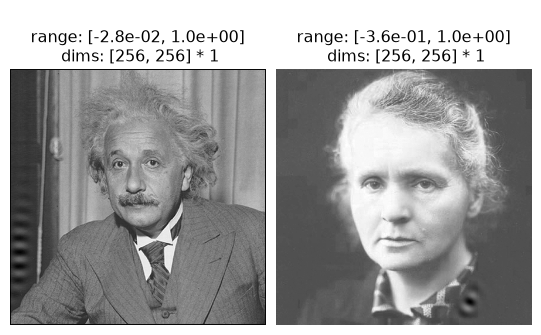

In [29]:
# the [:1] is a trick to get only the first element while still being a 4d
# tensor
po.plot.imshow(
    [
        img + 3 * lg_eig.eigendistortions[:1],
        curie + 3 * lg_curie_eig.eigendistortions[:1],
    ]
);

We can see that this exact placement matters by seeing what happens when we translate the eigendistortion on the Einstein image so it lies on his tie instead of in the dark part of the image:

Max LG eigendistortion: 0.0844364803814293
Shifted max LG eigendistortion: 0.03739753285230127


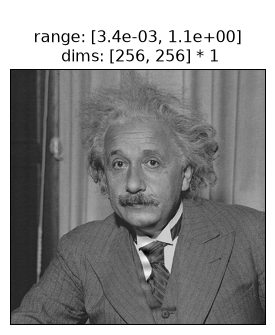

In [30]:
img_rep = lg(img)
eig_rep = lg(img + lg_eig.eigendistortions[:1])
shift_eig_rep = lg(img + lg_eig.eigendistortions[:1].roll(128, -1))
po.plot.imshow(img + 3 * lg_eig.eigendistortions[:1].roll(128, -1))
print(f"Max LG eigendistortion: {po.loss.l2_norm(img_rep, eig_rep)}")
print(f"Shifted max LG eigendistortion: {po.loss.l2_norm(img_rep, shift_eig_rep)}")

The difference between the model output of the proper maximum eigendistortion and the original image is larger than when we shift that eigendistortion.

However, translating the eigendistortion for the {class}`~plenoptic.models.CenterSurround` model has no effect on model output:

In [31]:
img_rep = center_surround(img)
eig_rep = center_surround(img + cs_eig.eigendistortions[:1])
shift_eig_rep = center_surround(img + cs_eig.eigendistortions[:1].roll(128, -1))
print(f"Max CenterSurround eigendistortion: {po.loss.l2_norm(img_rep, eig_rep)}")
print(
    "Shifted max CenterSurround eigendistortion: "
    f"{po.loss.l2_norm(img_rep, shift_eig_rep)}"
)

Max CenterSurround eigendistortion: 0.6446418189176387
Shifted max CenterSurround eigendistortion: 0.6446418189176388


We can thus see that the addition of gain control qualitatively changes the sensitivities of the model, making it less sensitive to the local luminance (as seen with the model metamers) but more sensitive to contrast, so that the placement of the distortions have a large effect on the size of their effect.

## Conclusion

<div class='render-all'>

In this notebook, we saw the basics of using `plenoptic` to investigate the sensitivities and invariances of some simple convolutional models, and reasoned through how the model metamers and eigendistortions we saw enable us to understand how these models process images.

`plenoptic` includes a variety of {ref}`models <models-api>` and {ref}`components <processing-api>` you can use to build models, and you can (and should!) use the synthesis methods with your own models.

Our documentation also has an example about [](deep_nets).

In order to use your own models with plenoptic, check the {ref}`models-doc` for the specific requirements, and use the {func}`~plenoptic.validate.validate_model` function to check compatibility. If you have issues or want feedback, we're happy to help --- just post on the [Github discussions page](https://github.com/plenoptic-org/plenoptic/discussions)!

</div>